# SkinLens AI

# Notebook 02

# Exploratory Data Analysis (EDA)

---

## Objectives

- Load metadata
- Understand dataset structure
- Analyze missing values
- Analyze target distribution
- Analyze patient information
- Explore metadata
- Visualize lesion images
- Detect data quality issues
- Prepare for preprocessing

In [1]:
# ============================================================
# Import Libraries
# ============================================================

import os
import random
from pathlib import Path

import cv2
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (10,6)

pd.set_option("display.max_columns", None)

# 1. Dataset Paths

In [2]:
# ============================================================
# Dataset Paths
# ============================================================

DATA_DIR = Path("/kaggle/input/competitions/isic-2024-challenge")

TRAIN_IMAGES = DATA_DIR / "train-image" / "image"

TRAIN_METADATA = DATA_DIR / "train-metadata.csv"

print(TRAIN_IMAGES)
print(TRAIN_METADATA)

/kaggle/input/competitions/isic-2024-challenge/train-image/image
/kaggle/input/competitions/isic-2024-challenge/train-metadata.csv


In [3]:
print(TRAIN_IMAGES.exists())
print(TRAIN_METADATA.exists())

True
True


# Load Metadata

In [4]:
# ============================================================
# Load Metadata
# ============================================================

df = pd.read_csv(TRAIN_METADATA)

/tmp/ipykernel_16/1802601114.py:5: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(TRAIN_METADATA)


In [5]:
print(df.shape)

(401059, 55)


In [6]:
df.head()


,isic_id,target,patient_id,age_approx,sex,anatom_site_general,clin_size_long_diam_mm,image_type,tbp_tile_type,tbp_lv_A,tbp_lv_Aext,tbp_lv_B,tbp_lv_Bext,tbp_lv_C,tbp_lv_Cext,tbp_lv_H,tbp_lv_Hext,tbp_lv_L,tbp_lv_Lext,tbp_lv_areaMM2,tbp_lv_area_perim_ratio,tbp_lv_color_std_mean,tbp_lv_deltaA,tbp_lv_deltaB,tbp_lv_deltaL,tbp_lv_deltaLB,tbp_lv_deltaLBnorm,tbp_lv_eccentricity,tbp_lv_location,tbp_lv_location_simple,tbp_lv_minorAxisMM,tbp_lv_nevi_confidence,tbp_lv_norm_border,tbp_lv_norm_color,tbp_lv_perimeterMM,tbp_lv_radial_color_std_max,tbp_lv_stdL,tbp_lv_stdLExt,tbp_lv_symm_2axis,tbp_lv_symm_2axis_angle,tbp_lv_x,tbp_lv_y,tbp_lv_z,attribution,copyright_license,lesion_id,iddx_full,iddx_1,iddx_2,iddx_3,iddx_4,iddx_5,mel_mitotic_index,mel_thick_mm,tbp_lv_dnn_lesion_confidence
0,ISIC_0015670,0,IP_1235828,60.0,male,lower extremity,3.04,TBP tile: close-up,3D: white,20.244422,16.261975,26.922447,23.954773,33.684638,28.953117,53.058545,55.828924,54.367448,62.025701,3.152561,27.476170,0.00000,3.982447,2.967674,-7.658253,8.360566,5.784302,0.901302,Right Leg - Upper,Right Leg,1.543016,2.628592e-03,7.091360,0.000000,9.307003,0.00000,2.036195,2.637780,0.590476,85,-182.703552,613.493652,-42.427948,Memorial Sloan Kettering Cancer Center,CC-BY,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,97.517282
1,ISIC_0015845,0,IP_8170065,60.0,male,head/neck,1.10,TBP tile: close-up,3D: white,31.712570,25.364740,26.331000,24.549290,41.219030,35.299260,39.702910,44.064040,48.861520,55.362360,0.919497,12.235290,0.00000,6.347830,1.781713,-6.500838,6.839008,4.987244,0.639885,Head & Neck,Head & Neck,0.821918,1.334303e-07,2.116402,0.000000,3.354148,0.00000,0.853227,3.912844,0.285714,55,-0.078308,1575.687000,57.174500,Memorial Sloan Kettering Cancer Center,CC-BY,IL_6727506,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,3.141455
2,ISIC_0015864,0,IP_6724798,60.0,male,posterior torso,3.40,TBP tile: close-up,3D: XP,22.575830,17.128170,37.970460,33.485410,44.174920,37.611800,59.265850,62.909730,53.961180,61.670520,3.265153,24.184620,0.00000,5.447655,4.485044,-7.709336,9.092376,6.290359,0.932147,Torso Back Top Third,Torso Back,1.194905,2.959177e-04,4.798335,0.000000,8.886309,0.00000,1.743651,1.950777,0.361905,105,123.649700,1472.010000,232.908900,Memorial Sloan Kettering Cancer Center,CC-BY,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.804040
3,ISIC_0015902,0,IP_4111386,65.0,male,anterior torso,3.22,TBP tile: close-up,3D: XP,14.242329,12.164757,21.448144,21.121356,25.746200,24.374023,56.414429,60.060388,18.649518,23.314841,6.079940,14.889242,0.51452,2.077572,0.326788,-4.665323,4.783413,6.400196,0.654458,Torso Front Top Half,Torso Front,2.481328,2.198945e+01,1.975874,1.771705,9.514499,0.66469,1.258541,1.573733,0.209581,130,-141.024780,1442.185791,58.359802,ACEMID MIA,CC-0,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.989998
4,ISIC_0024200,0,IP_8313778,55.0,male,anterior torso,2.73,TBP tile: close-up,3D: white,24.725520,20.057470,26.464900,25.710460,36.217980,32.608740,46.946070,52.041180,46.276310,54.855740,2.101708,19.902560,0.00000,4.668053,0.754434,-8.579431,9.148495,6.531302,0.946448,Torso Front Top Half,Torso Front,0.929916,1.378832e-03,3.658854,0.000000,6.467562,0.00000,2.085409,2.480509,0.313433,20,-72.315640,1488.720000,21.428960,Memorial Sloan Kettering Cancer Center,CC-BY,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,70.442510


In [7]:
df.sample(5)

,isic_id,target,patient_id,age_approx,sex,anatom_site_general,clin_size_long_diam_mm,image_type,tbp_tile_type,tbp_lv_A,tbp_lv_Aext,tbp_lv_B,tbp_lv_Bext,tbp_lv_C,tbp_lv_Cext,tbp_lv_H,tbp_lv_Hext,tbp_lv_L,tbp_lv_Lext,tbp_lv_areaMM2,tbp_lv_area_perim_ratio,tbp_lv_color_std_mean,tbp_lv_deltaA,tbp_lv_deltaB,tbp_lv_deltaL,tbp_lv_deltaLB,tbp_lv_deltaLBnorm,tbp_lv_eccentricity,tbp_lv_location,tbp_lv_location_simple,tbp_lv_minorAxisMM,tbp_lv_nevi_confidence,tbp_lv_norm_border,tbp_lv_norm_color,tbp_lv_perimeterMM,tbp_lv_radial_color_std_max,tbp_lv_stdL,tbp_lv_stdLExt,tbp_lv_symm_2axis,tbp_lv_symm_2axis_angle,tbp_lv_x,tbp_lv_y,tbp_lv_z,attribution,copyright_license,lesion_id,iddx_full,iddx_1,iddx_2,iddx_3,iddx_4,iddx_5,mel_mitotic_index,mel_thick_mm,tbp_lv_dnn_lesion_confidence
188286,ISIC_4741892,0,IP_4745071,70.0,female,posterior torso,7.34,TBP tile: close-up,3D: white,18.760318,13.696671,31.430152,30.893693,36.603333,33.793772,59.167479,66.089970,53.597647,67.527438,18.896603,18.879360,2.171512,5.063647,0.536459,-13.929791,14.193516,9.294054,0.903715,Torso Back Middle Third,Torso Back,3.355624,4.086191e+01,2.618899,6.467597,18.887980,2.144477,5.156238,2.172888,0.198214,30,-34.142902,1057.847778,134.648010,Memorial Sloan Kettering Cancer Center,CC-BY,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,98.853254
342912,ISIC_8566312,0,IP_1117889,55.0,female,lower extremity,4.53,TBP tile: close-up,3D: XP,18.684396,15.595836,26.183278,23.843213,32.166297,28.490856,54.488333,56.811316,33.137073,38.380296,5.066617,24.660112,0.632306,3.088560,2.340065,-5.243223,5.921132,5.741276,0.949643,Left Leg - Upper,Left Leg,1.531553,3.822142e-09,4.689285,1.472671,11.177805,0.355751,1.398635,2.076299,0.335484,150,-63.173218,569.529358,1.196533,"Department of Dermatology, Hospital Clínic de ...",CC-BY-NC,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,57.356131
340783,ISIC_8515942,0,IP_8478332,75.0,male,lower extremity,3.02,TBP tile: close-up,3D: XP,22.466690,20.388790,26.414790,26.912530,34.676990,33.763690,49.617700,52.852630,25.240830,31.183890,3.021205,19.676520,0.000000,2.077900,-0.497737,-5.943063,6.071532,6.495894,0.913343,Left Leg - Lower,Left Leg,1.303980,3.681096e-07,5.116594,0.000000,7.710174,0.000000,1.187606,2.328427,0.515790,170,-273.475800,243.433000,53.936100,"Department of Dermatology, Hospital Clínic de ...",CC-BY-NC,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,97.963730
20875,ISIC_0586528,0,IP_3927284,55.0,male,anterior torso,3.10,TBP tile: close-up,3D: white,19.227616,14.129070,33.945696,29.814275,39.012965,32.992751,60.471795,64.643592,62.008325,70.477838,5.629574,16.419203,0.953361,5.098545,4.131421,-8.469513,9.497090,6.078926,0.689568,Torso Front Top Half,Torso Front,2.324735,1.422914e+01,2.936905,2.353195,9.614215,0.623270,1.949422,2.295742,0.301676,45,-205.798645,1400.362183,-83.160400,Memorial Sloan Kettering Cancer Center,CC-BY,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,100.000000
248081,ISIC_6233996,0,IP_2224950,70.0,male,upper extremity,2.60,TBP tile: close-up,3D: XP,22.641505,19.142771,28.988689,28.157274,36.782901,34.048168,52.008520,55.790107,46.261352,52.355561,3.058735,20.424019,0.341409,3.498733,0.831415,-6.094210,6.466306,4.839791,0.737583,Left Arm - Lower,Left Arm,1.780822,6.604399e-02,4.862967,1.306382,7.903902,0.526630,0.877578,3.298287,0.463158,5,-306.678955,1127.161743,-91.413879,"Frazer Institute, The University of Queensland...",CC-BY,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,94.382799


# Dataset Information

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 401059 entries, 0 to 401058
Data columns (total 55 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   isic_id                       401059 non-null  object 
 1   target                        401059 non-null  int64  
 2   patient_id                    401059 non-null  object 
 3   age_approx                    398261 non-null  float64
 4   sex                           389542 non-null  object 
 5   anatom_site_general           395303 non-null  object 
 6   clin_size_long_diam_mm        401059 non-null  float64
 7   image_type                    401059 non-null  object 
 8   tbp_tile_type                 401059 non-null  object 
 9   tbp_lv_A                      401059 non-null  float64
 10  tbp_lv_Aext                   401059 non-null  float64
 11  tbp_lv_B                      401059 non-null  float64
 12  tbp_lv_Bext                   401059 non-nul

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
target,401059.0,0.000980,0.031288,0.000000e+00,0.000000,0.000000,0.000000,1.000000
age_approx,398261.0,58.012986,13.596165,5.000000e+00,50.000000,60.000000,70.000000,85.000000
clin_size_long_diam_mm,401059.0,3.930827,1.743068,1.000000e+00,2.840000,3.370000,4.380000,28.400000
tbp_lv_A,401059.0,19.974007,3.999489,-2.487115e+00,17.330821,19.801910,22.304628,48.189610
tbp_lv_Aext,401059.0,14.919247,3.529384,-9.080269e+00,12.469740,14.713930,17.137175,37.021680
tbp_lv_B,401059.0,28.281706,5.278676,-7.309895e-01,24.704372,28.171570,31.637429,54.306900
tbp_lv_Bext,401059.0,26.913015,4.482994,9.237066e+00,23.848125,26.701704,29.679913,48.372700
tbp_lv_C,401059.0,34.786341,5.708469,3.054228e+00,31.003148,34.822580,38.430298,58.765170
tbp_lv_Cext,401059.0,30.921279,4.829345,1.184652e+01,27.658285,30.804893,33.963868,54.305290
tbp_lv_H,401059.0,54.653689,5.520849,-1.574164e+00,51.566273,55.035632,58.298184,105.875784


In [10]:
df.describe(include="object").T

,count,unique,top,freq
isic_id,401059,401059,ISIC_9999967,1
patient_id,401059,1042,IP_1117889,9184
sex,389542,2,male,265546
anatom_site_general,395303,5,posterior torso,121902
image_type,401059,1,TBP tile: close-up,401059
tbp_tile_type,401059,2,3D: XP,285903
tbp_lv_location,401059,21,Torso Back Top Third,71112
tbp_lv_location_simple,401059,8,Torso Back,121902
attribution,401059,7,Memorial Sloan Kettering Cancer Center,129068
copyright_license,401059,3,CC-BY,188812


# Column Names

In [11]:
for i, col in enumerate(df.columns,1):
    print(f"{i}. {col}")

1. isic_id
2. target
3. patient_id
4. age_approx
5. sex
6. anatom_site_general
7. clin_size_long_diam_mm
8. image_type
9. tbp_tile_type
10. tbp_lv_A
11. tbp_lv_Aext
12. tbp_lv_B
13. tbp_lv_Bext
14. tbp_lv_C
15. tbp_lv_Cext
16. tbp_lv_H
17. tbp_lv_Hext
18. tbp_lv_L
19. tbp_lv_Lext
20. tbp_lv_areaMM2
21. tbp_lv_area_perim_ratio
22. tbp_lv_color_std_mean
23. tbp_lv_deltaA
24. tbp_lv_deltaB
25. tbp_lv_deltaL
26. tbp_lv_deltaLB
27. tbp_lv_deltaLBnorm
28. tbp_lv_eccentricity
29. tbp_lv_location
30. tbp_lv_location_simple
31. tbp_lv_minorAxisMM
32. tbp_lv_nevi_confidence
33. tbp_lv_norm_border
34. tbp_lv_norm_color
35. tbp_lv_perimeterMM
36. tbp_lv_radial_color_std_max
37. tbp_lv_stdL
38. tbp_lv_stdLExt
39. tbp_lv_symm_2axis
40. tbp_lv_symm_2axis_angle
41. tbp_lv_x
42. tbp_lv_y
43. tbp_lv_z
44. attribution
45. copyright_license
46. lesion_id
47. iddx_full
48. iddx_1
49. iddx_2
50. iddx_3
51. iddx_4
52. iddx_5
53. mel_mitotic_index
54. mel_thick_mm
55. tbp_lv_dnn_lesion_confidence


# Data Types

In [12]:
dtype_df = pd.DataFrame({

    "Column":df.columns,

    "Datatype":df.dtypes.values

})

dtype_df

,Column,Datatype
0,isic_id,object
1,target,int64
2,patient_id,object
3,age_approx,float64
4,sex,object
5,anatom_site_general,object
6,clin_size_long_diam_mm,float64
7,image_type,object
8,tbp_tile_type,object
9,tbp_lv_A,float64


# Missing Values

In [13]:
missing = df.isnull().sum()

missing = missing.sort_values(ascending=False)

missing

iddx_5                          401058
mel_mitotic_index               401006
mel_thick_mm                    400996
iddx_4                          400508
iddx_3                          399994
iddx_2                          399991
lesion_id                       379001
sex                              11517
anatom_site_general               5756
age_approx                        2798
image_type                           0
tbp_lv_B                             0
tbp_lv_Bext                          0
tbp_lv_C                             0
tbp_lv_Cext                          0
tbp_lv_H                             0
tbp_tile_type                        0
tbp_lv_A                             0
tbp_lv_Aext                          0
patient_id                           0
target                               0
isic_id                              0
clin_size_long_diam_mm               0
tbp_lv_deltaA                        0
tbp_lv_color_std_mean                0
tbp_lv_area_perim_ratio  

In [14]:
missing_percent = (

    df.isnull().mean()*100

).sort_values(ascending=False)

missing_percent.head(20)

iddx_5                 99.999751
mel_mitotic_index      99.986785
mel_thick_mm           99.984292
iddx_4                 99.862614
iddx_3                 99.734453
iddx_2                 99.733705
lesion_id              94.500061
sex                     2.871647
anatom_site_general     1.435200
age_approx              0.697653
image_type              0.000000
tbp_lv_B                0.000000
tbp_lv_Bext             0.000000
tbp_lv_C                0.000000
tbp_lv_Cext             0.000000
tbp_lv_H                0.000000
tbp_tile_type           0.000000
tbp_lv_A                0.000000
tbp_lv_Aext             0.000000
patient_id              0.000000
dtype: float64

In [15]:
missing_df = pd.DataFrame({

    "Missing":missing,

    "Percentage":missing_percent

})

missing_df.head(20)

,Missing,Percentage
iddx_5,401058,99.999751
mel_mitotic_index,401006,99.986785
mel_thick_mm,400996,99.984292
iddx_4,400508,99.862614
iddx_3,399994,99.734453
iddx_2,399991,99.733705
lesion_id,379001,94.500061
sex,11517,2.871647
anatom_site_general,5756,1.435200
age_approx,2798,0.697653


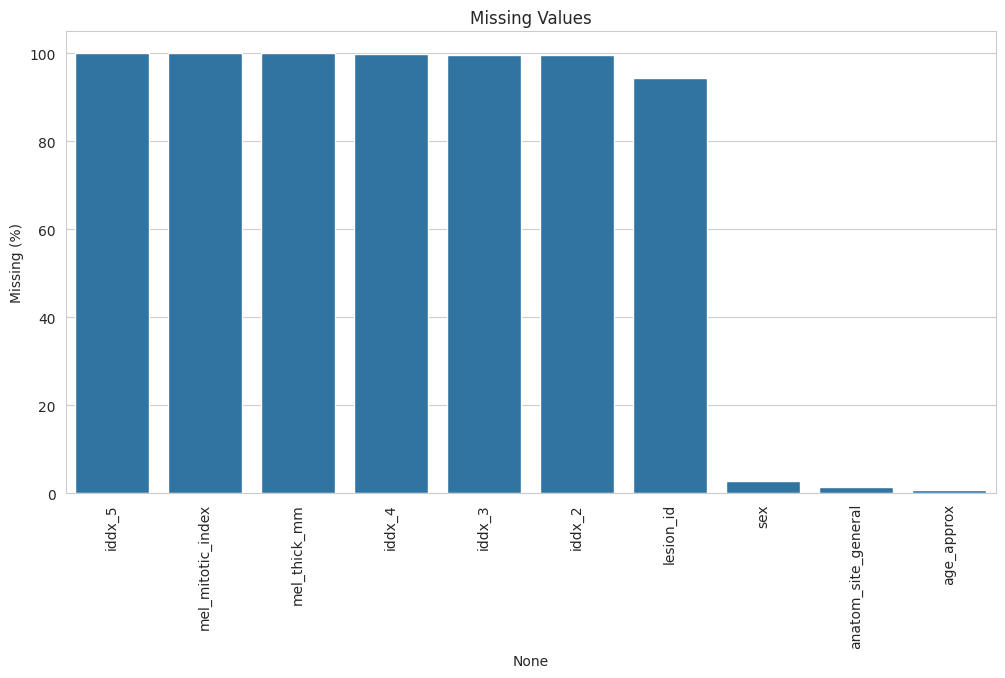

In [16]:
plt.figure(figsize=(12,6))

missing_df = missing_df[missing_df["Missing"]>0]

sns.barplot(

    x=missing_df.index,

    y=missing_df["Percentage"]

)

plt.xticks(rotation=90)

plt.ylabel("Missing (%)")

plt.title("Missing Values")

plt.show()

# Duplicate Analysis

In [17]:
duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)

Duplicate Rows : 0


In [18]:
duplicate_ids = df["isic_id"].duplicated().sum()

print("Duplicate ISIC IDs :", duplicate_ids)

Duplicate ISIC IDs : 0


# Memory Usage

In [19]:
memory = (

df.memory_usage(deep=True)

/

1024**2

)

memory.sort_values(ascending=False)

attribution                     43.980115
tbp_lv_location                 25.803959
image_type                      25.626138
anatom_site_general             24.150408
isic_id                         23.331260
patient_id                      22.566300
tbp_lv_location_simple          22.394200
tbp_tile_type                   21.365846
copyright_license               21.151797
iddx_full                       21.116440
iddx_1                          21.038267
sex                             20.277273
lesion_id                       12.807325
iddx_2                          12.296979
iddx_3                          12.271693
iddx_4                          12.265923
mel_mitotic_index               12.240534
iddx_5                          12.239385
tbp_lv_A                         3.059837
tbp_lv_Aext                      3.059837
tbp_lv_H                         3.059837
clin_size_long_diam_mm           3.059837
age_approx                       3.059837
target                           3

In [20]:
print(

f"Total Memory : {memory.sum():.2f} MB"

)

Total Memory : 480.14 MB


# Target Variable

In [21]:
print(df["target"].value_counts())

target
0    400666
1       393
Name: count, dtype: int64


In [22]:
print(

df["target"].value_counts(normalize=True)*100

)

target
0    99.902009
1     0.097991
Name: proportion, dtype: float64


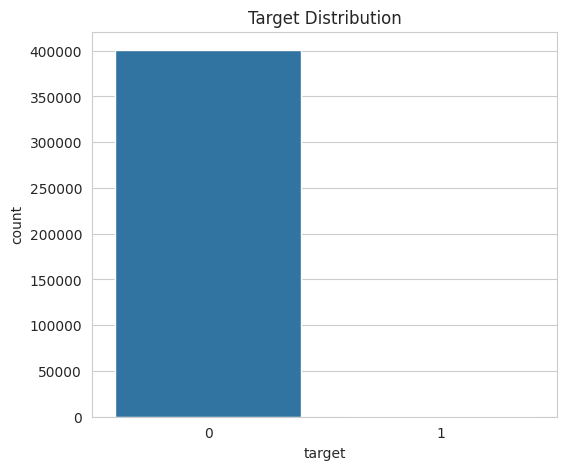

In [23]:
plt.figure(figsize=(6,5))

sns.countplot(

data=df,

x="target"

)

plt.title("Target Distribution")

plt.show()

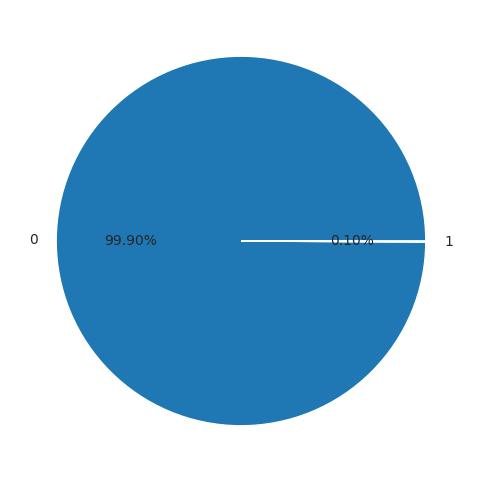

In [24]:
target = df["target"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(

target,

labels=target.index,

autopct="%1.2f%%"

)

plt.show()

# Dataset Summary

In [25]:
summary = {

"Rows":df.shape[0],

"Columns":df.shape[1],

"Duplicate Rows":duplicates,

"Unique Patients":df["patient_id"].nunique(),

"Unique Images":df["isic_id"].nunique(),

"Missing Columns":missing_df.shape[0],

"Positive Cases":df["target"].sum(),

"Negative Cases":len(df)-df["target"].sum()

}

summary

{'Rows': 401059,
 'Columns': 55,
 'Duplicate Rows': np.int64(0),
 'Unique Patients': 1042,
 'Unique Images': 401059,
 'Missing Columns': 10,
 'Positive Cases': np.int64(393),
 'Negative Cases': np.int64(400666)}

In [26]:
pd.DataFrame(

summary.items(),

columns=["Metric","Value"]

)

,Metric,Value
0,Rows,401059
1,Columns,55
2,Duplicate Rows,0
3,Unique Patients,1042
4,Unique Images,401059
5,Missing Columns,10
6,Positive Cases,393
7,Negative Cases,400666


# EDA Conclusion (Part 1)

✔ Metadata Loaded Successfully

✔ Dataset Structure Understood

✔ Missing Values Identified

✔ Duplicate Analysis Completed

✔ Target Distribution Visualized

✔ Ready for Patient-Level Analysis

# Patient Analysis

One patient may have multiple lesion images.

We must understand this before creating train/validation splits to avoid data leakage.

In [27]:
# Number of unique patients

unique_patients = df["patient_id"].nunique()

print(f"Unique Patients : {unique_patients:,}")

Unique Patients : 1,042


In [28]:
# Images per patient

patient_counts = df.groupby("patient_id").size()

patient_counts.describe()

count    1042.000000
mean      384.893474
std       540.268913
min         1.000000
25%       115.000000
50%       241.500000
75%       477.500000
max      9184.000000
dtype: float64

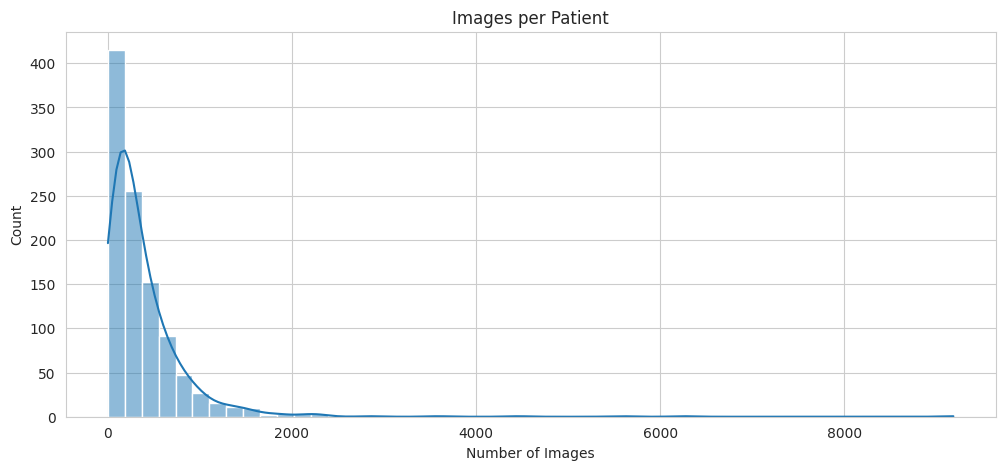

In [29]:
plt.figure(figsize=(12,5))

sns.histplot(
    patient_counts,
    bins=50,
    kde=True
)

plt.title("Images per Patient")

plt.xlabel("Number of Images")

plt.show()

In [30]:
print("Maximum Images of One Patient")

patient_counts.max()

Maximum Images of One Patient


9184

# Patient Target Distribution

In [31]:
patient_target = (

    df.groupby("patient_id")["target"]

    .sum()

    .sort_values(ascending=False)

)

patient_target.head()

patient_id
IP_2456971    14
IP_1959239     8
IP_0669361     7
IP_9324599     7
IP_3905195     6
Name: target, dtype: int64

# Age Analysis

In [32]:
age_col = "age_approx"

print(df[age_col].describe())

count    398261.000000
mean         58.012986
std          13.596165
min           5.000000
25%          50.000000
50%          60.000000
75%          70.000000
max          85.000000
Name: age_approx, dtype: float64


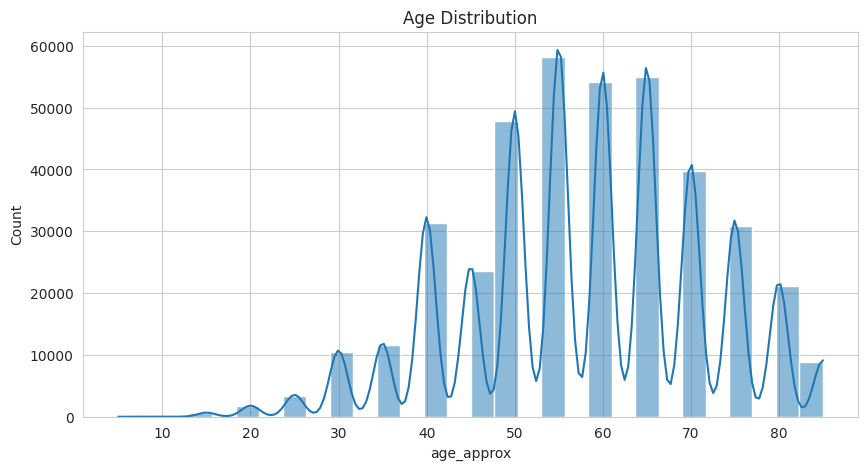

In [33]:
plt.figure(figsize=(10,5))

sns.histplot(

    df[age_col],

    bins=30,

    kde=True

)

plt.title("Age Distribution")

plt.show()

In [34]:
print("Youngest Age :", df[age_col].min())

print("Oldest Age :", df[age_col].max())

Youngest Age : 5.0
Oldest Age : 85.0


# Sex Distribution

In [35]:
df["sex"].value_counts(dropna=False)

sex
male      265546
female    123996
NaN        11517
Name: count, dtype: int64

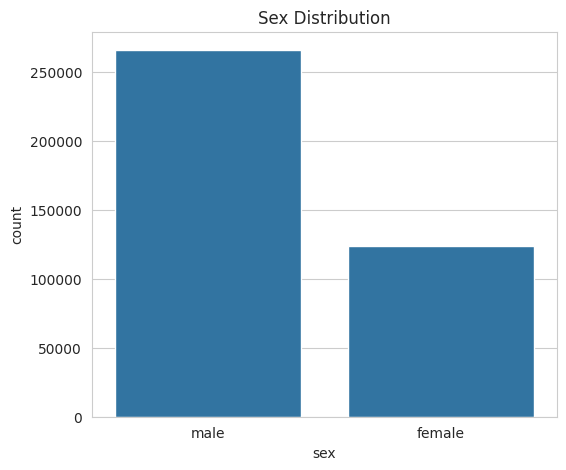

In [36]:
plt.figure(figsize=(6,5))

sns.countplot(

data=df,

x="sex"

)

plt.title("Sex Distribution")

plt.show()

In [37]:
sex_target = pd.crosstab(

    df["sex"],

    df["target"]

)

sex_target

target,0,1
sex,,
female,123887,109
male,265272,274


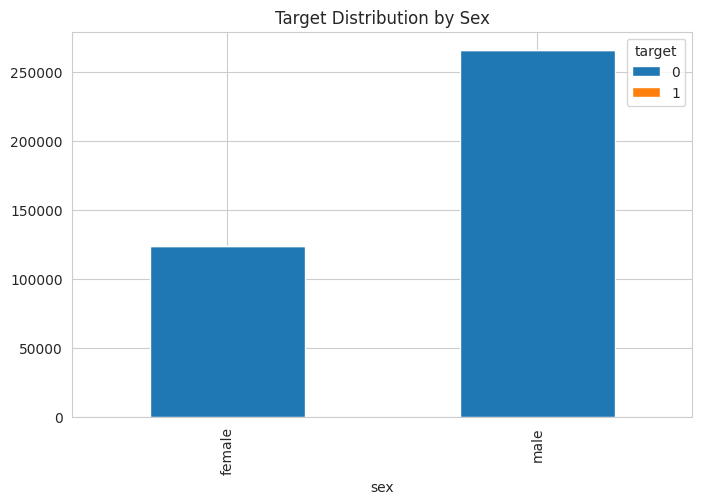

In [38]:
sex_target.plot(

kind="bar",

stacked=True,

figsize=(8,5)

)

plt.title("Target Distribution by Sex")

plt.show()

# Anatomical Site Analysis

In [39]:
# Find columns related to anatomy

[col for col in df.columns if "anatom" in col.lower()]

['anatom_site_general']

In [40]:
site_column = "anatom_site_general"

df[site_column].value_counts(dropna=False)

anatom_site_general
posterior torso    121902
lower extremity    103028
anterior torso      87770
upper extremity     70557
head/neck           12046
NaN                  5756
Name: count, dtype: int64

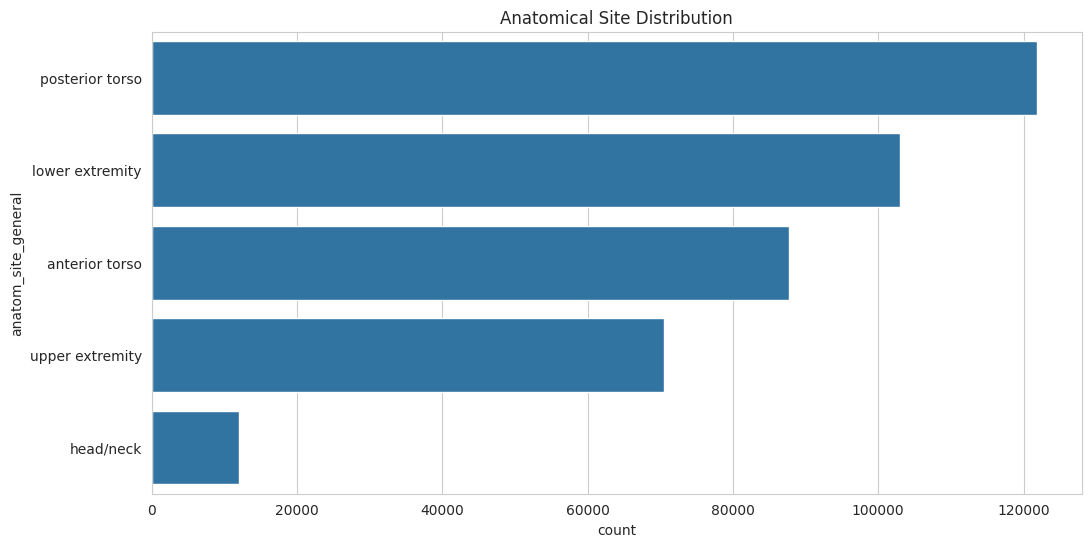

In [41]:
plt.figure(figsize=(12,6))

sns.countplot(

data=df,

y=site_column,

order=df[site_column].value_counts().index

)

plt.title("Anatomical Site Distribution")

plt.show()

# Image Count Verification

In [42]:
image_files = list(TRAIN_IMAGES.glob("*.jpg"))

print("Images Folder :", len(image_files))

print("Metadata Rows :", len(df))

Images Folder : 401059
Metadata Rows : 401059


In [43]:
if len(image_files)==len(df):

    print("Dataset is Complete ✅")

else:

    print("Mismatch Found ⚠")

Dataset is Complete ✅


# Random Metadata Sample

In [44]:
df.sample(10)

,isic_id,target,patient_id,age_approx,sex,anatom_site_general,clin_size_long_diam_mm,image_type,tbp_tile_type,tbp_lv_A,tbp_lv_Aext,tbp_lv_B,tbp_lv_Bext,tbp_lv_C,tbp_lv_Cext,tbp_lv_H,tbp_lv_Hext,tbp_lv_L,tbp_lv_Lext,tbp_lv_areaMM2,tbp_lv_area_perim_ratio,tbp_lv_color_std_mean,tbp_lv_deltaA,tbp_lv_deltaB,tbp_lv_deltaL,tbp_lv_deltaLB,tbp_lv_deltaLBnorm,tbp_lv_eccentricity,tbp_lv_location,tbp_lv_location_simple,tbp_lv_minorAxisMM,tbp_lv_nevi_confidence,tbp_lv_norm_border,tbp_lv_norm_color,tbp_lv_perimeterMM,tbp_lv_radial_color_std_max,tbp_lv_stdL,tbp_lv_stdLExt,tbp_lv_symm_2axis,tbp_lv_symm_2axis_angle,tbp_lv_x,tbp_lv_y,tbp_lv_z,attribution,copyright_license,lesion_id,iddx_full,iddx_1,iddx_2,iddx_3,iddx_4,iddx_5,mel_mitotic_index,mel_thick_mm,tbp_lv_dnn_lesion_confidence
100221,ISIC_2555613,0,IP_8989787,40.0,male,posterior torso,10.90,TBP tile: close-up,3D: white,18.512290,11.200560,23.446370,24.340990,29.873680,26.794330,51.706830,65.290370,51.553230,65.892360,49.183710,24.891290,2.550059,7.311727,-0.894620,-14.339130,14.494410,9.818007,0.856327,Torso Back Middle Third,Torso Back,6.279147,9.676765e+01,4.309915,8.746781,34.989230,3.457378,5.288445,2.468941,0.278581,10,-92.896300,1220.457000,149.477000,Memorial Sloan Kettering Cancer Center,CC-BY,IL_3240565,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.991820
30699,ISIC_0828520,0,IP_1117889,55.0,female,posterior torso,4.26,TBP tile: close-up,3D: XP,19.493634,16.358453,29.759456,26.896903,35.575652,31.480826,56.773598,58.692412,41.759508,47.885553,6.492775,20.482389,0.630328,3.135181,2.862553,-6.126045,6.980599,5.744086,0.887197,Torso Back Middle Third,Torso Back,2.403367,6.987947e-10,4.797731,1.382802,11.532023,0.298842,1.845567,2.357450,0.452915,20,-129.383545,972.085327,97.265594,"Department of Dermatology, Hospital Clínic de ...",CC-BY-NC,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,97.991538
275488,ISIC_6900302,0,IP_0869661,70.0,male,upper extremity,2.90,TBP tile: close-up,3D: XP,21.450888,16.519213,33.028993,33.226721,39.383436,37.106595,56.998037,63.564973,42.017469,49.147613,4.484894,18.982183,0.939986,4.931675,-0.197728,-7.130144,7.296130,5.928163,0.657381,Right Arm - Upper,Right Arm,2.054795,2.248254e+01,3.774749,2.391267,9.226759,0.661044,1.609898,2.497710,0.351724,10,283.642090,1340.088257,131.358093,University Hospital of Basel,CC-BY-NC,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.987686
247954,ISIC_6230287,0,IP_8442778,25.0,female,posterior torso,2.64,TBP tile: close-up,3D: white,18.944470,14.510870,31.774940,28.170450,36.993780,31.688160,59.196260,62.746570,62.709670,70.095830,4.297242,20.858360,0.350670,4.433607,3.604493,-7.386162,8.306285,5.297552,0.472942,Torso Back Top Third,Torso Back,2.293569,8.720428e-03,5.815634,1.403378,9.467493,0.581200,1.149733,2.348192,0.581081,115,-145.739700,1332.908000,87.423220,Memorial Sloan Kettering Cancer Center,CC-BY,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.998760
189107,ISIC_4762140,0,IP_4039962,70.0,male,anterior torso,5.21,TBP tile: close-up,3D: white,15.940381,13.658615,16.521285,19.580714,22.957539,23.873879,46.025203,55.102125,20.848025,27.595543,12.966786,17.089670,0.892823,2.281765,-3.059429,-6.747519,7.509723,9.069570,0.811766,Torso Front Bottom Half,Torso Front,3.057842,7.350090e+01,3.044866,3.089411,14.886171,1.163257,1.736093,1.394952,0.299754,160,81.712067,848.371033,-70.115845,Memorial Sloan Kettering Cancer Center,CC-BY,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.920952
316972,ISIC_7924760,0,IP_8528263,40.0,female,posterior torso,2.80,TBP tile: close-up,3D: XP,26.547160,16.018060,40.305730,37.482150,48.262860,40.761380,56.629310,66.860480,47.283090,60.392120,5.197973,14.490610,0.979271,10.529100,2.823573,-13.109030,13.561270,9.644405,0.529439,Torso Back Top Third,Torso Back,2.266699,9.862944e+01,2.049285,2.730575,8.678814,0.845315,4.343928,1.944911,0.229299,140,122.459800,1400.515000,139.964700,University Hospital of Basel,CC-BY-NC,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,100.000000
34173,ISIC_0914205,0,IP_2331257,55.

# Class Imbalance Ratio

In [45]:
positive = df["target"].sum()

negative = len(df)-positive

print("Benign :",negative)

print("Malignant :",positive)

Benign : 400666
Malignant : 393


In [46]:
ratio = negative/positive

print(f"Class Imbalance Ratio : {ratio:.2f}:1")

Class Imbalance Ratio : 1019.51:1


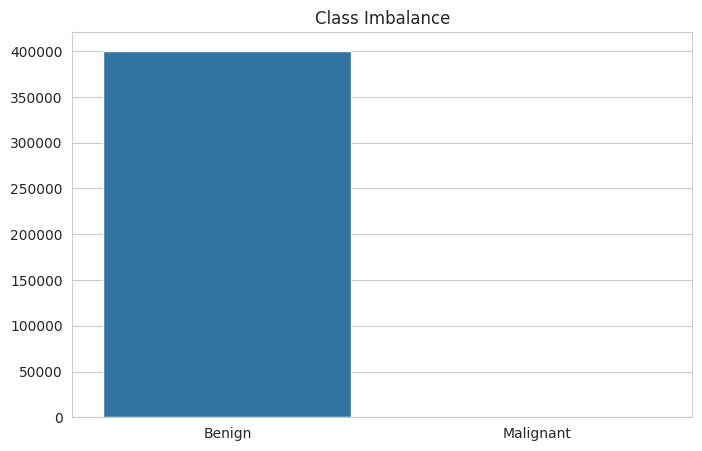

In [47]:
plt.figure(figsize=(8,5))

sns.barplot(

x=["Benign","Malignant"],

y=[negative,positive]

)

plt.title("Class Imbalance")

plt.show()

# Summary

✔ Patient Analysis Completed

✔ Age Distribution Completed

✔ Sex Analysis Completed

✔ Anatomical Site Analysis Completed

✔ Dataset Consistency Verified

✔ Class Imbalance Understood

# Numerical Feature Analysis

In this section we will:

- Identify numerical columns
- Generate descriptive statistics
- Visualize feature distributions
- Detect skewness
- Detect outliers

In [48]:
# Numerical Columns

numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

print(f"Total Numerical Columns : {len(numerical_cols)}")

numerical_cols

Total Numerical Columns : 37


['target',
 'age_approx',
 'clin_size_long_diam_mm',
 'tbp_lv_A',
 'tbp_lv_Aext',
 'tbp_lv_B',
 'tbp_lv_Bext',
 'tbp_lv_C',
 'tbp_lv_Cext',
 'tbp_lv_H',
 'tbp_lv_Hext',
 'tbp_lv_L',
 'tbp_lv_Lext',
 'tbp_lv_areaMM2',
 'tbp_lv_area_perim_ratio',
 'tbp_lv_color_std_mean',
 'tbp_lv_deltaA',
 'tbp_lv_deltaB',
 'tbp_lv_deltaL',
 'tbp_lv_deltaLB',
 'tbp_lv_deltaLBnorm',
 'tbp_lv_eccentricity',
 'tbp_lv_minorAxisMM',
 'tbp_lv_nevi_confidence',
 'tbp_lv_norm_border',
 'tbp_lv_norm_color',
 'tbp_lv_perimeterMM',
 'tbp_lv_radial_color_std_max',
 'tbp_lv_stdL',
 'tbp_lv_stdLExt',
 'tbp_lv_symm_2axis',
 'tbp_lv_symm_2axis_angle',
 'tbp_lv_x',
 'tbp_lv_y',
 'tbp_lv_z',
 'mel_thick_mm',
 'tbp_lv_dnn_lesion_confidence']

In [49]:
# Summary Statistics

df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
target,401059.0,0.000980,0.031288,0.000000e+00,0.000000,0.000000,0.000000,1.000000
age_approx,398261.0,58.012986,13.596165,5.000000e+00,50.000000,60.000000,70.000000,85.000000
clin_size_long_diam_mm,401059.0,3.930827,1.743068,1.000000e+00,2.840000,3.370000,4.380000,28.400000
tbp_lv_A,401059.0,19.974007,3.999489,-2.487115e+00,17.330821,19.801910,22.304628,48.189610
tbp_lv_Aext,401059.0,14.919247,3.529384,-9.080269e+00,12.469740,14.713930,17.137175,37.021680
tbp_lv_B,401059.0,28.281706,5.278676,-7.309895e-01,24.704372,28.171570,31.637429,54.306900
tbp_lv_Bext,401059.0,26.913015,4.482994,9.237066e+00,23.848125,26.701704,29.679913,48.372700
tbp_lv_C,401059.0,34.786341,5.708469,3.054228e+00,31.003148,34.822580,38.430298,58.765170
tbp_lv_Cext,401059.0,30.921279,4.829345,1.184652e+01,27.658285,30.804893,33.963868,54.305290
tbp_lv_H,401059.0,54.653689,5.520849,-1.574164e+00,51.566273,55.035632,58.298184,105.875784


In [50]:
# Missing values in numerical columns

df[numerical_cols].isnull().sum().sort_values(ascending=False)

mel_thick_mm                    400996
age_approx                        2798
target                               0
tbp_lv_A                             0
clin_size_long_diam_mm               0
tbp_lv_Aext                          0
tbp_lv_B                             0
tbp_lv_C                             0
tbp_lv_Bext                          0
tbp_lv_H                             0
tbp_lv_Hext                          0
tbp_lv_L                             0
tbp_lv_Cext                          0
tbp_lv_areaMM2                       0
tbp_lv_area_perim_ratio              0
tbp_lv_color_std_mean                0
tbp_lv_deltaA                        0
tbp_lv_deltaB                        0
tbp_lv_deltaL                        0
tbp_lv_deltaLB                       0
tbp_lv_Lext                          0
tbp_lv_deltaLBnorm                   0
tbp_lv_eccentricity                  0
tbp_lv_nevi_confidence               0
tbp_lv_minorAxisMM                   0
tbp_lv_norm_color        

# Histograms

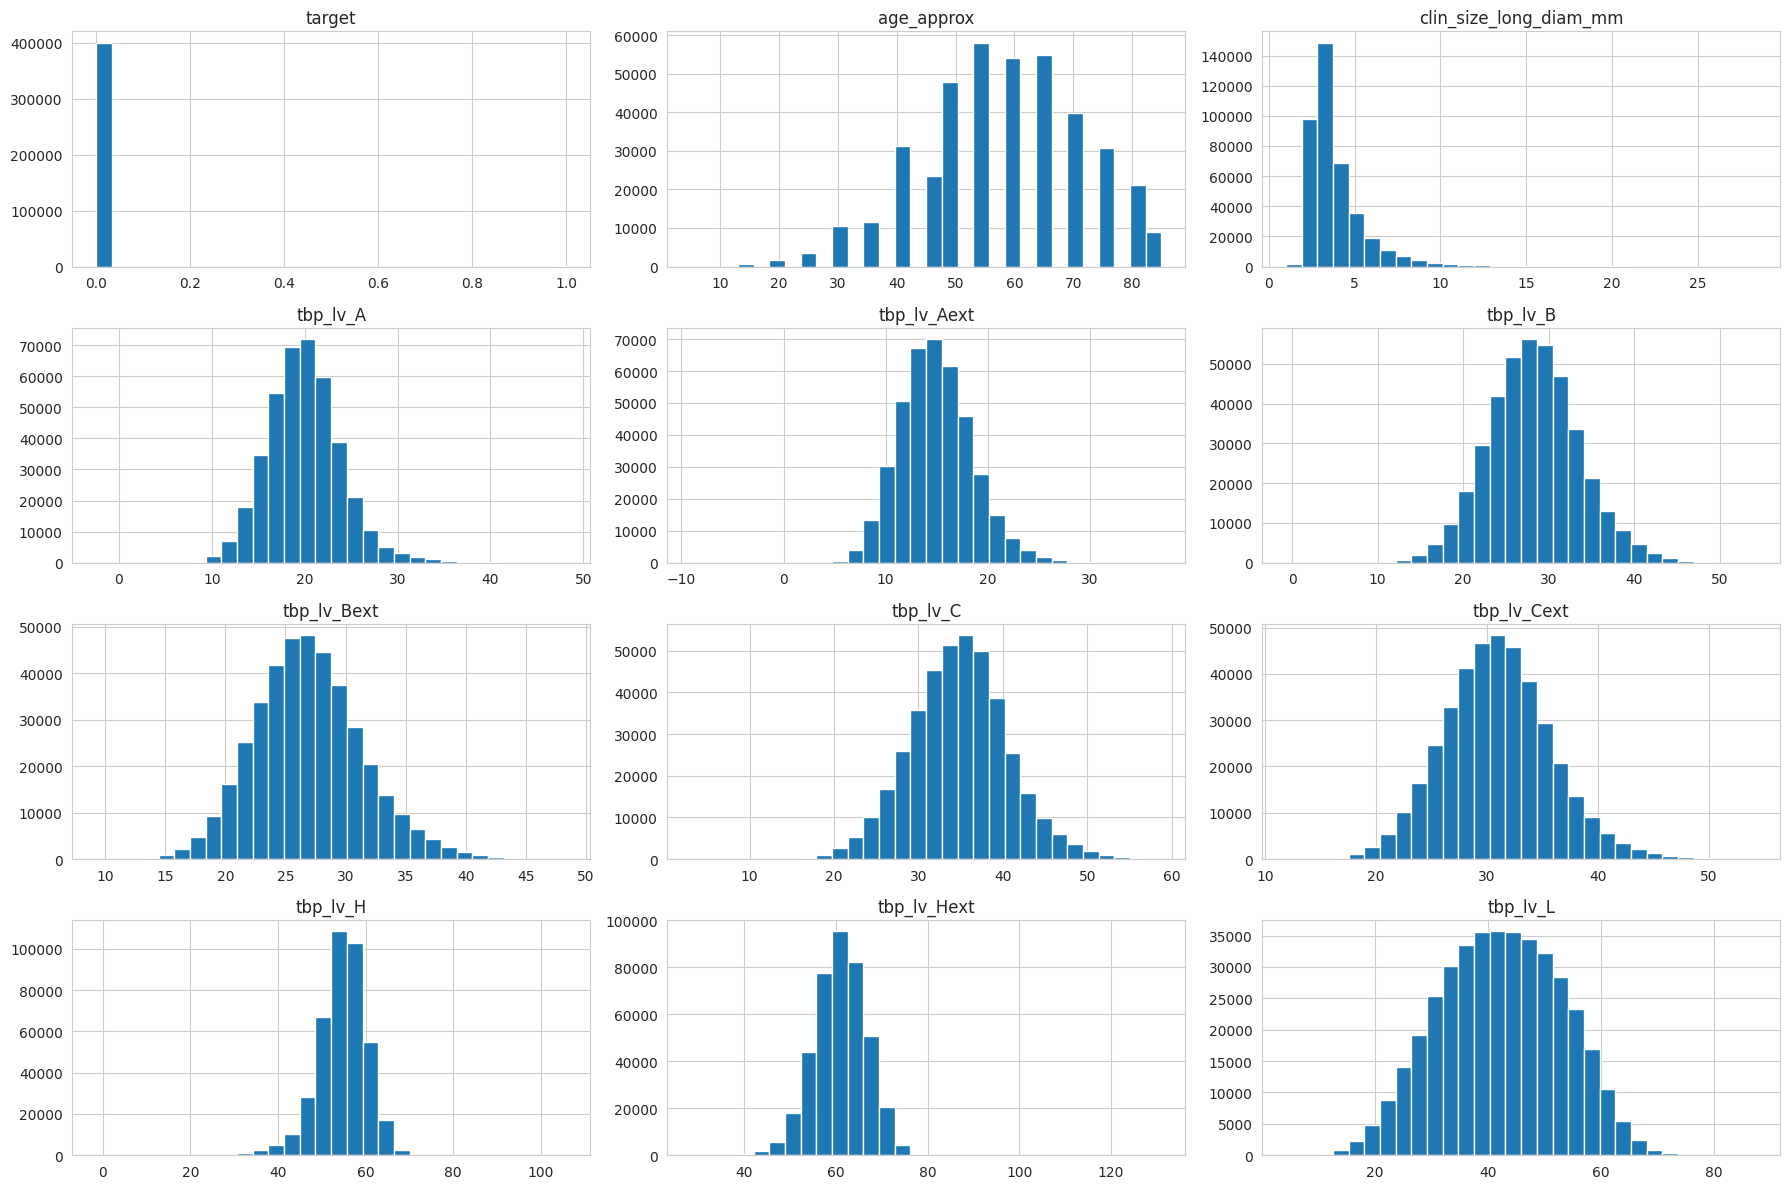

In [51]:
# Plot first 12 numerical columns

cols = numerical_cols[:12]

df[cols].hist(
    figsize=(18,12),
    bins=30
)

plt.tight_layout()
plt.show()

# Distribution Plots

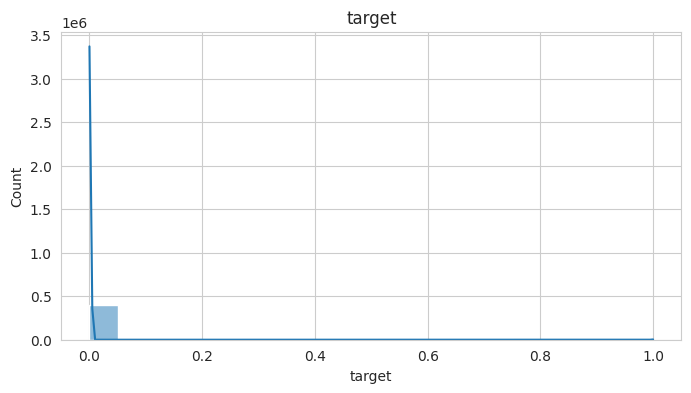

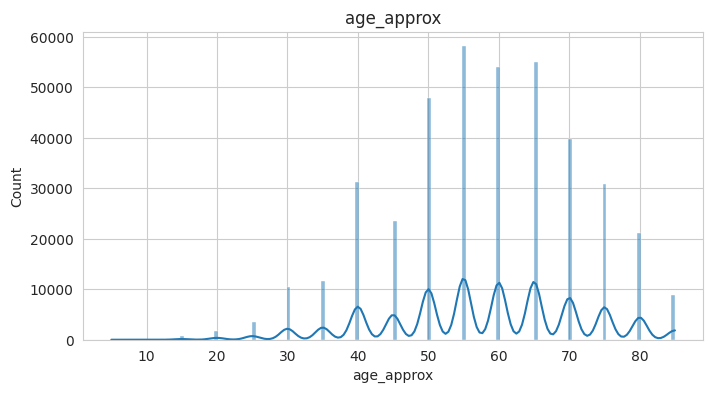

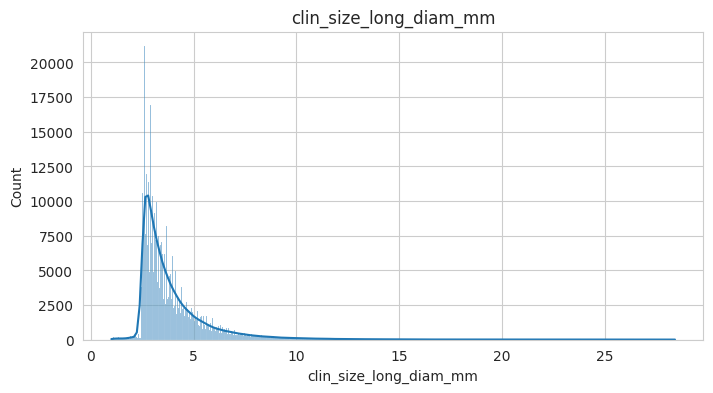

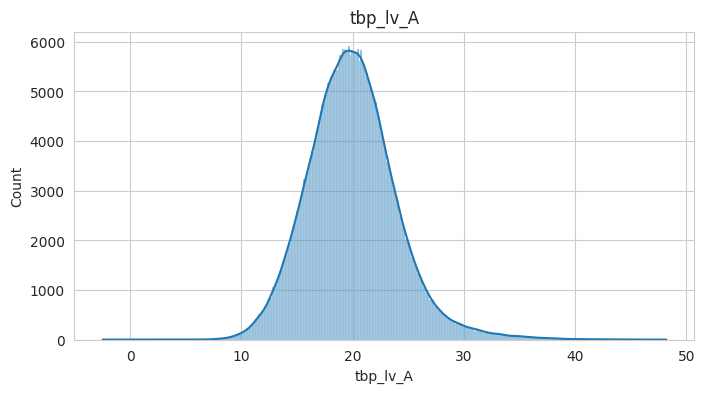

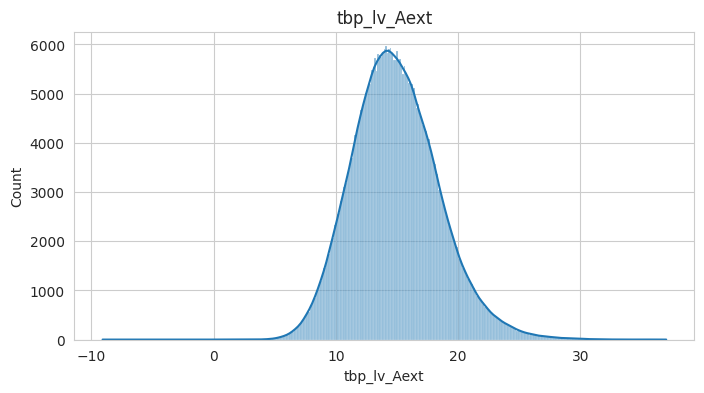

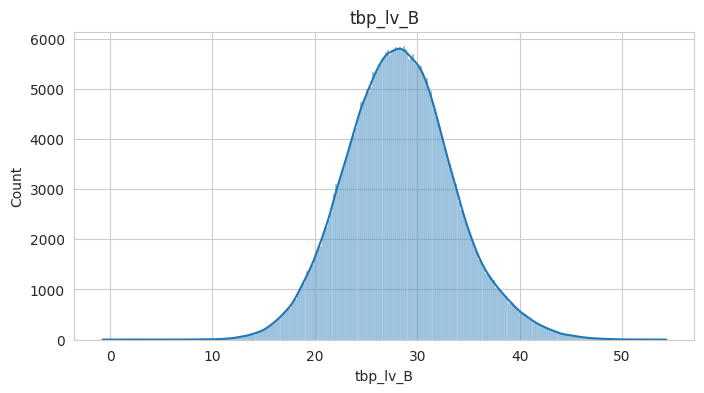

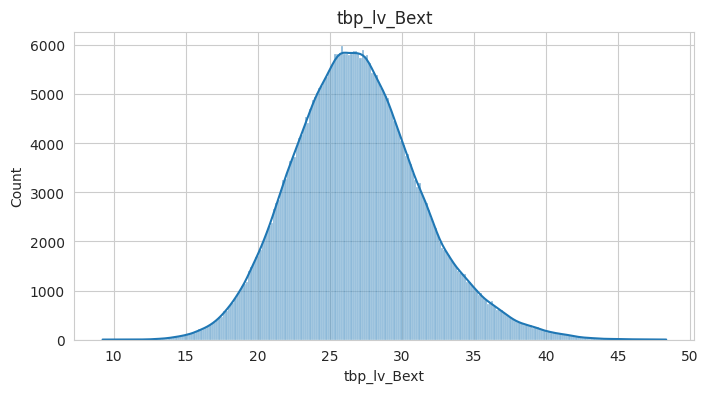

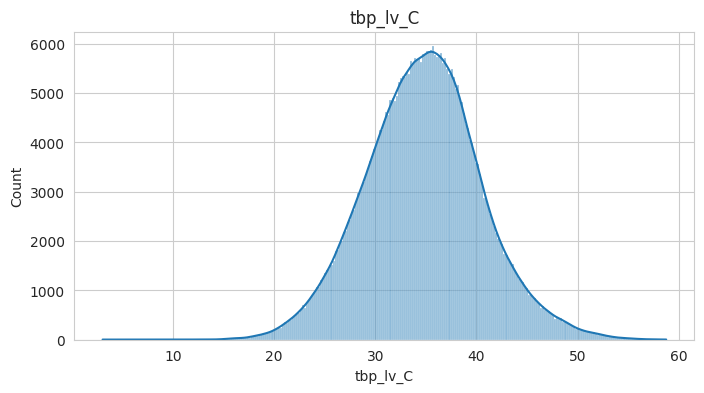

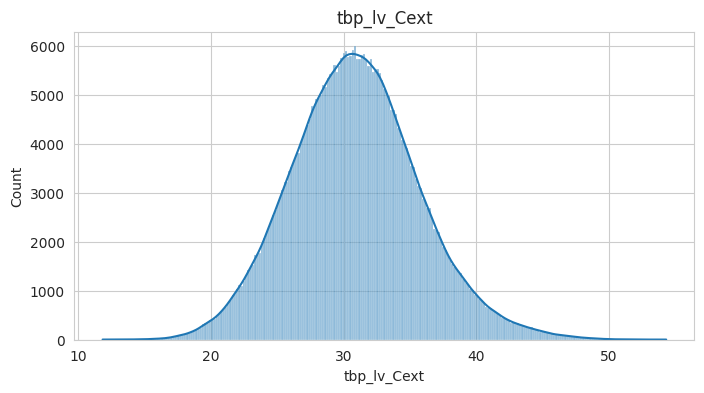

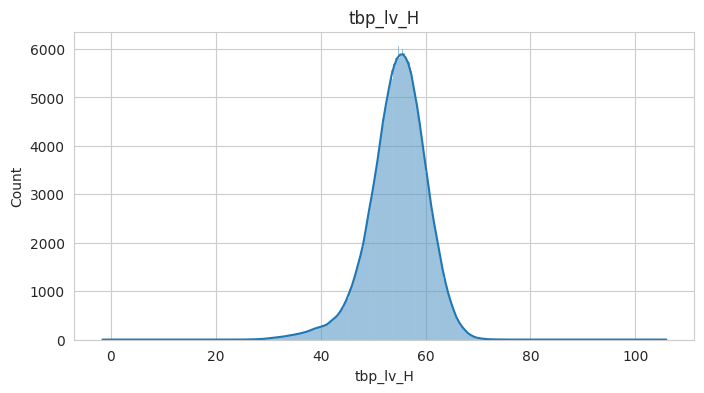

In [52]:
for col in numerical_cols[:10]:

    plt.figure(figsize=(8,4))

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(col)

    plt.show()

# Boxplots (Outlier Detection)

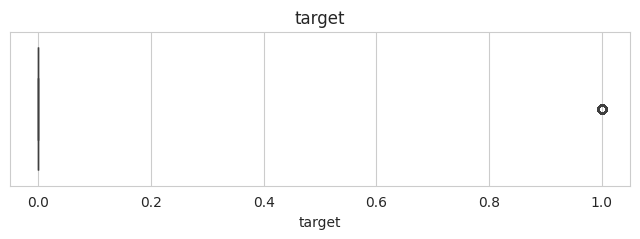

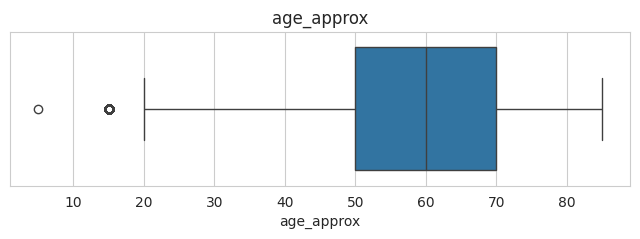

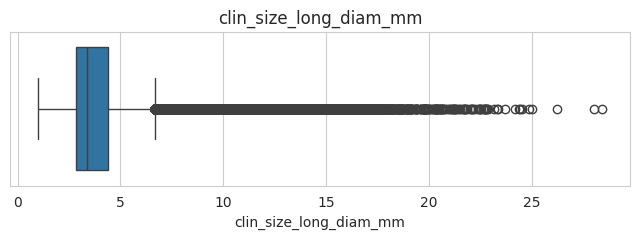

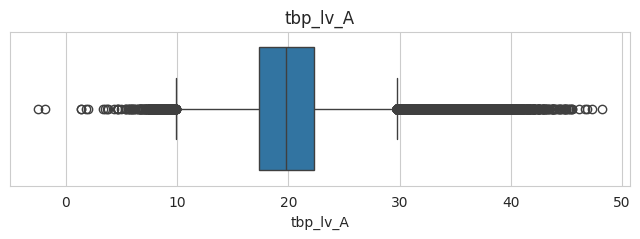

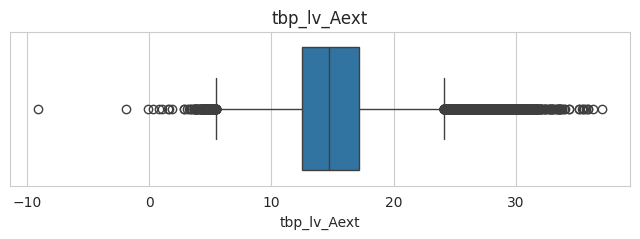

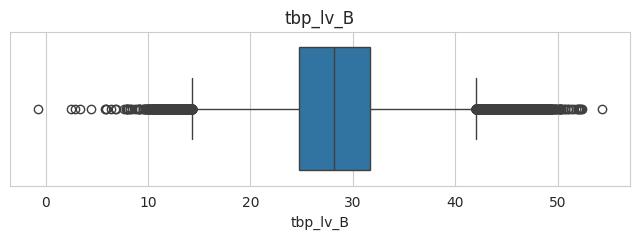

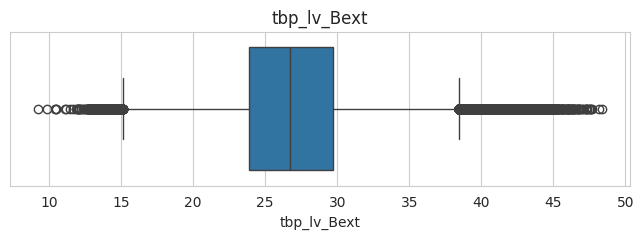

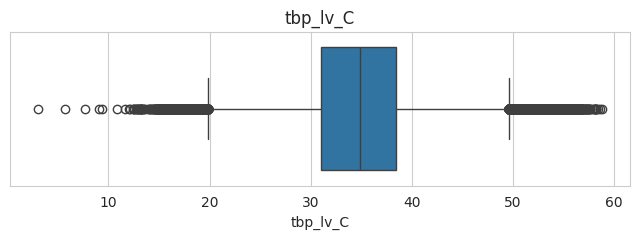

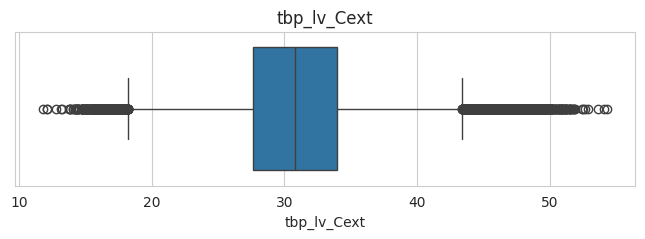

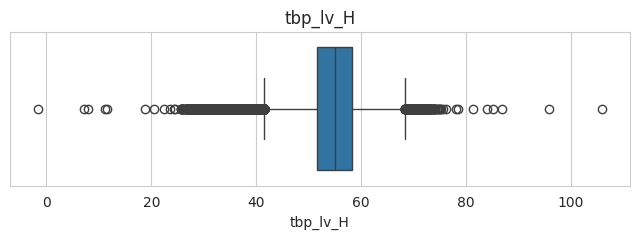

In [53]:
for col in numerical_cols[:10]:

    plt.figure(figsize=(8,2))

    sns.boxplot(
        x=df[col]
    )

    plt.title(col)

    plt.show()

# Correlation Matrix

In [54]:
corr = df[numerical_cols].corr()

corr.head()

,target,age_approx,clin_size_long_diam_mm,tbp_lv_A,tbp_lv_Aext,tbp_lv_B,tbp_lv_Bext,tbp_lv_C,tbp_lv_Cext,tbp_lv_H,tbp_lv_Hext,tbp_lv_L,tbp_lv_Lext,tbp_lv_areaMM2,tbp_lv_area_perim_ratio,tbp_lv_color_std_mean,tbp_lv_deltaA,tbp_lv_deltaB,tbp_lv_deltaL,tbp_lv_deltaLB,tbp_lv_deltaLBnorm,tbp_lv_eccentricity,tbp_lv_minorAxisMM,tbp_lv_nevi_confidence,tbp_lv_norm_border,tbp_lv_norm_color,tbp_lv_perimeterMM,tbp_lv_radial_color_std_max,tbp_lv_stdL,tbp_lv_stdLExt,tbp_lv_symm_2axis,tbp_lv_symm_2axis_angle,tbp_lv_x,tbp_lv_y,tbp_lv_z,mel_thick_mm,tbp_lv_dnn_lesion_confidence
target,1.000000,0.007734,0.032682,0.019788,0.023206,-0.026366,-0.013711,-0.009431,-0.000807,-0.044884,-0.032671,-0.004053,-0.000417,0.045139,0.009624,0.024271,-0.001046,-0.035069,-0.011256,0.012237,0.015172,-0.005295,0.035757,-0.013341,0.006747,0.022264,0.036188,0.025441,0.012669,0.026084,0.002583,0.000867,-0.002652,0.009926,-0.007896,NaN,-0.054766
age_approx,0.007734,1.000000,0.016160,-0.010769,0.121040,-0.087802,-0.062579,-0.069054,-0.008615,-0.074416,-0.168048,-0.077823,-0.125966,-0.015647,0.181630,-0.076770,-0.177898,-0.082390,0.196032,-0.196661,-0.172622,0.100439,-0.021973,-0.285836,0.207641,-0.070458,0.033006,-0.049960,-0.163012,0.090737,0.198716,0.004545,0.013595,-0.018804,-0.023817,-0.080273,-0.099672
clin_size_long_diam_mm,0.032682,0.016160,1.000000,-0.043167,-0.075178,-0.118330,-0.037388,-0.108182,-0.056407,-0.069811,0.048127,-0.074518,-0.005368,0.902768,0.478078,0.497229,0.035069,-0.206246,-0.215007,0.201913,0.238330,0.119727,0.858842,0.058120,0.268672,0.499650,0.965004,0.464033,0.235598,0.180026,0.017673,0.007453,-0.000696,0.021320,-0.007704,0.435815,-0.080093
tbp_lv_A,0.019788,-0.010769,-0.043167,1.000000,0.760407,0.417361,0.490904,0.736131,0.675600,-0.571710,-0.418779,0.311349,0.367616,-0.025180,-0.078353,0.094474,0.497827,0.001081,-0.307697,0.303209,0.111847,-0.051384,-0.021112,0.054253,-0.083821,0.093426,-0.047431,0.082424,0.191993,0.139608,-0.073930,-0.005565,0.007303,0.217637,0.027398,-0.422305,0.145164
tbp_lv_Aext,0.023206,0.121040,-0.075178,0.760407,1.000000,0.245170,0.356352,0.495618,0.650936,-0.511267,-0.748907,0.150641,0.101165,-0.096634,0.164587,-0.166624,-0.184699,-0.136899,0.119104,-0.126344,-0.249228,0.099519,-0.109939,-0.263145,0.203346,-0.154987,-0.054264,-0.129133,-0.183322,0.162648,0.209659,0.001797,0.013792,0.202624,0.047441,-0.157602,-0.028886


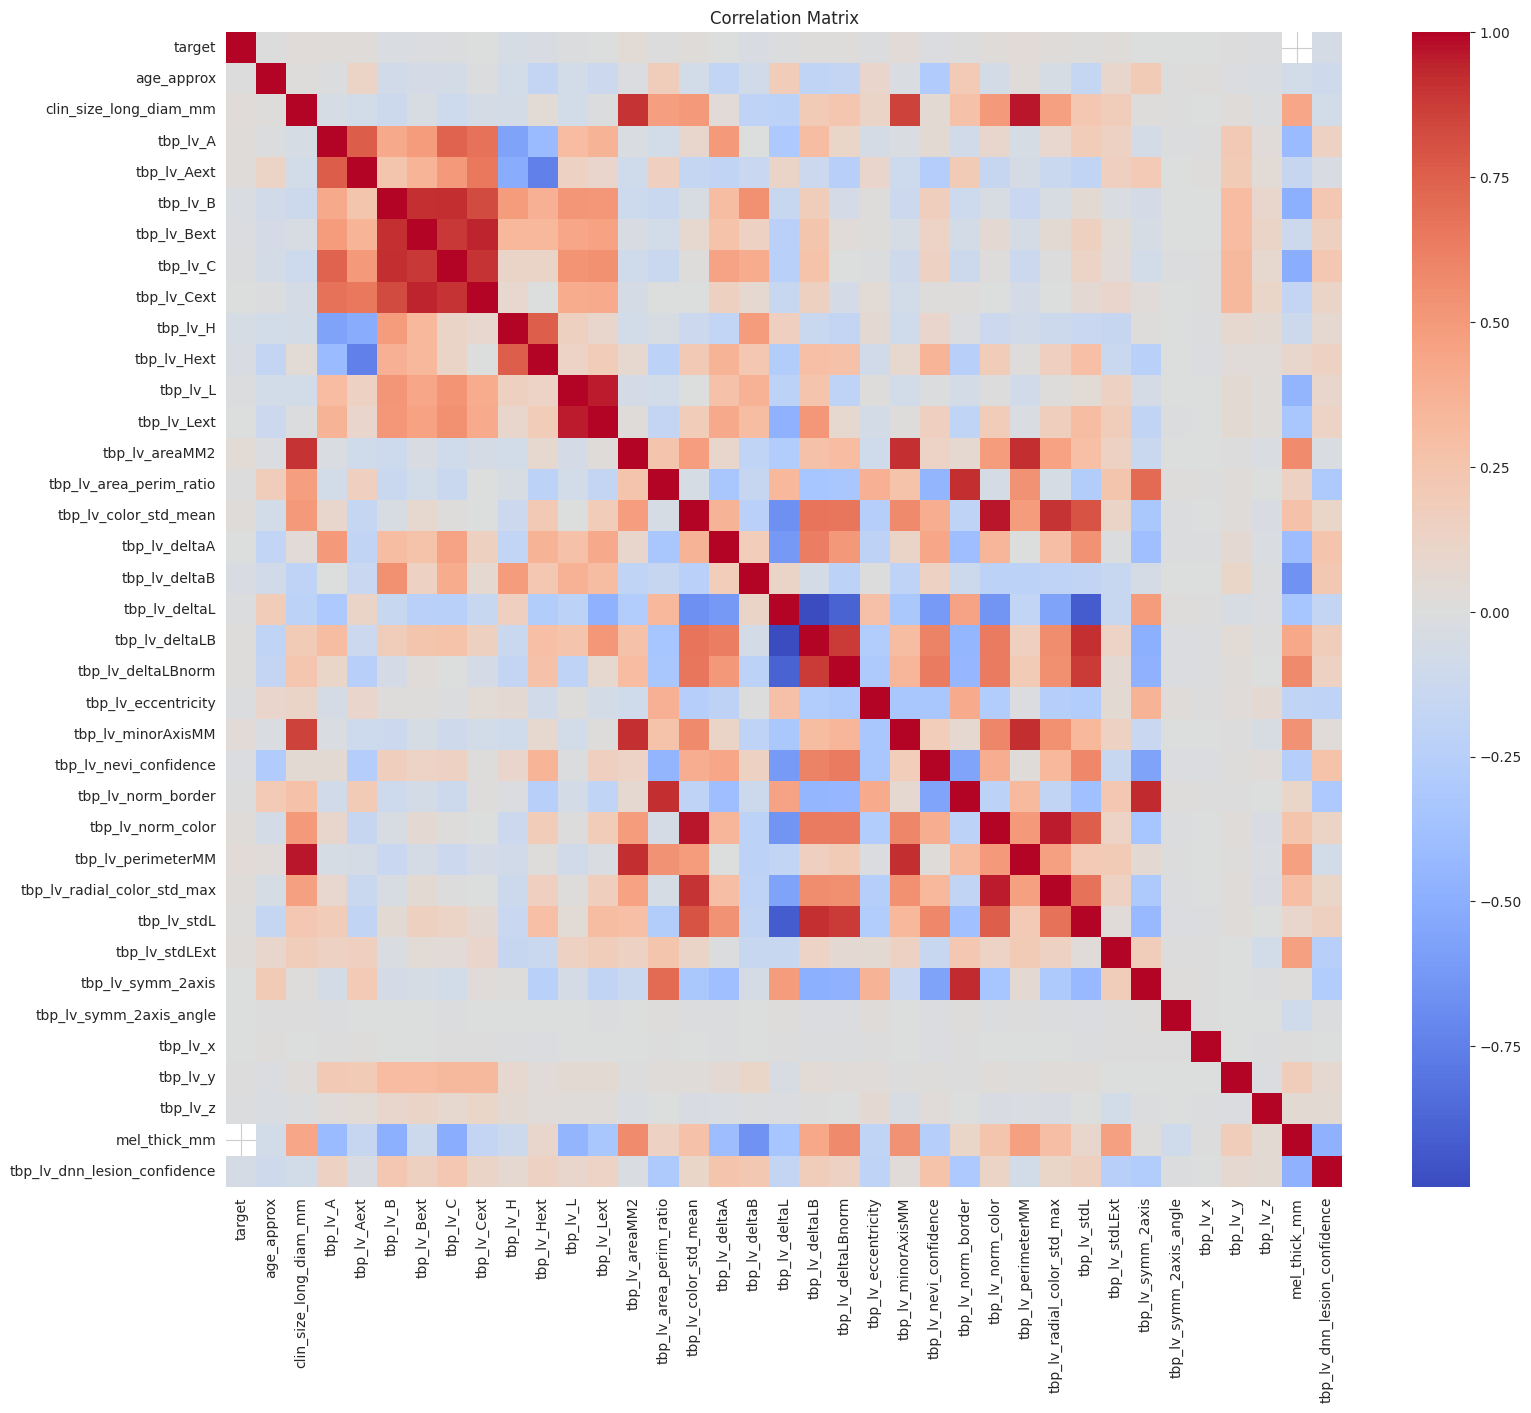

In [55]:
plt.figure(figsize=(18,15))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

# Correlation with Target

In [56]:
target_corr = (

    corr["target"]

    .sort_values(
        ascending=False
    )

)

target_corr

target                          1.000000
tbp_lv_areaMM2                  0.045139
tbp_lv_perimeterMM              0.036188
tbp_lv_minorAxisMM              0.035757
clin_size_long_diam_mm          0.032682
tbp_lv_stdLExt                  0.026084
tbp_lv_radial_color_std_max     0.025441
tbp_lv_color_std_mean           0.024271
tbp_lv_Aext                     0.023206
tbp_lv_norm_color               0.022264
tbp_lv_A                        0.019788
tbp_lv_deltaLBnorm              0.015172
tbp_lv_stdL                     0.012669
tbp_lv_deltaLB                  0.012237
tbp_lv_y                        0.009926
tbp_lv_area_perim_ratio         0.009624
age_approx                      0.007734
tbp_lv_norm_border              0.006747
tbp_lv_symm_2axis               0.002583
tbp_lv_symm_2axis_angle         0.000867
tbp_lv_Lext                    -0.000417
tbp_lv_Cext                    -0.000807
tbp_lv_deltaA                  -0.001046
tbp_lv_x                       -0.002652
tbp_lv_L        

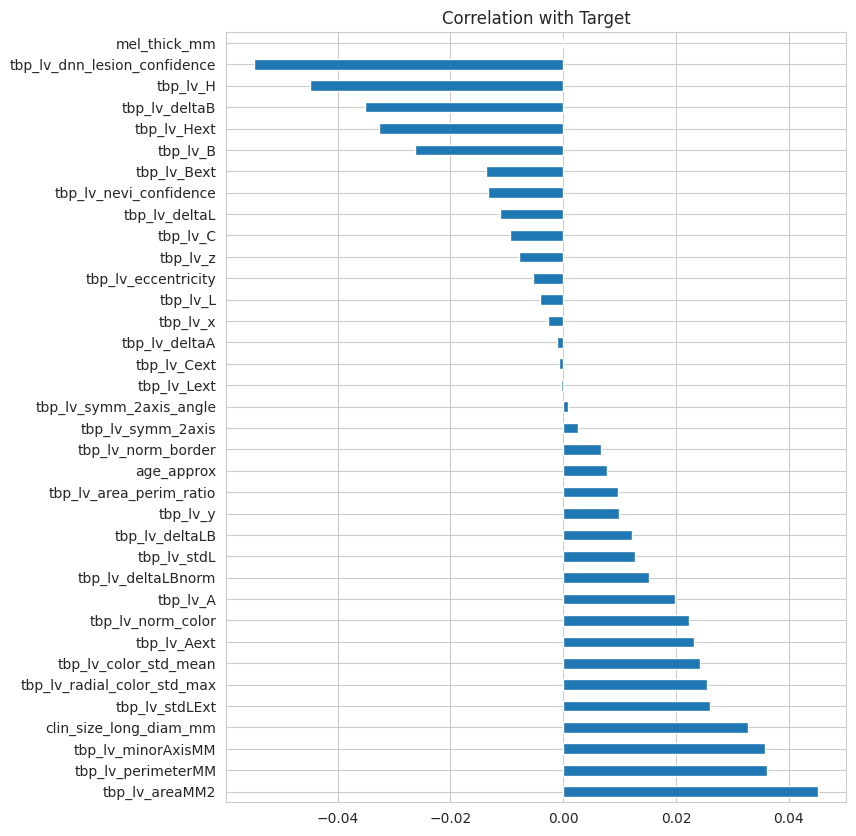

In [57]:
plt.figure(figsize=(8,10))

target_corr.drop("target").plot.barh()

plt.title("Correlation with Target")

plt.show()

# Target-wise Feature Analysis

In [58]:
top_features = target_corr.index[1:6]

top_features

Index(['tbp_lv_areaMM2', 'tbp_lv_perimeterMM', 'tbp_lv_minorAxisMM',
       'clin_size_long_diam_mm', 'tbp_lv_stdLExt'],
      dtype='object')

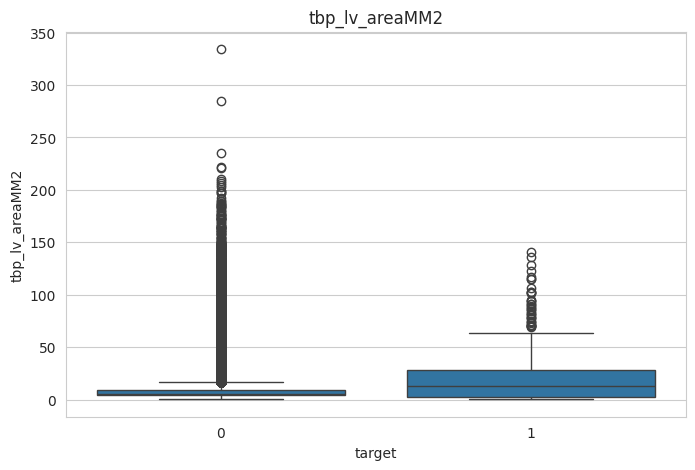

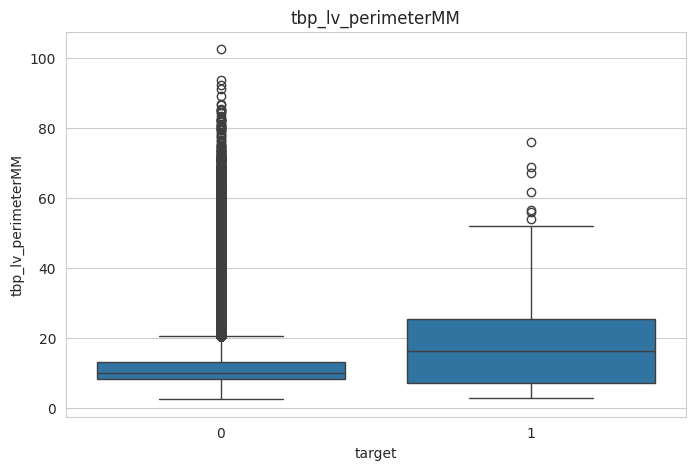

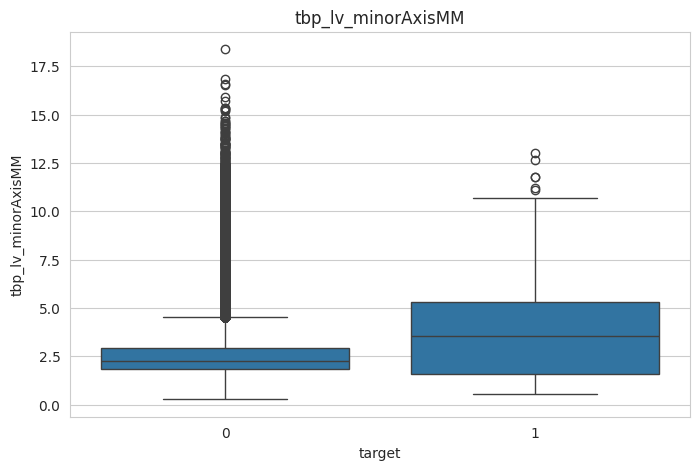

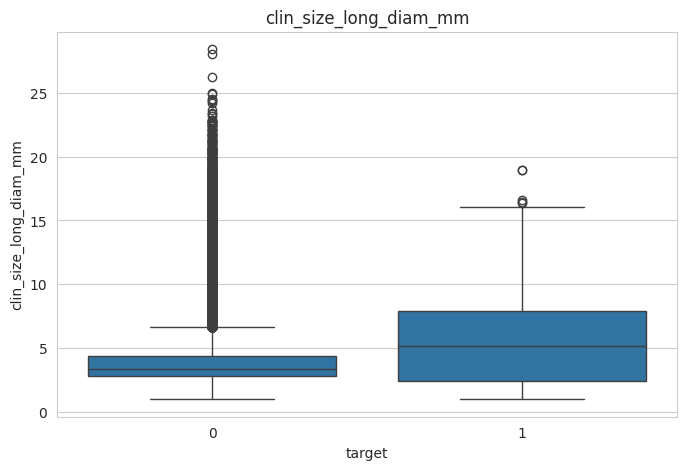

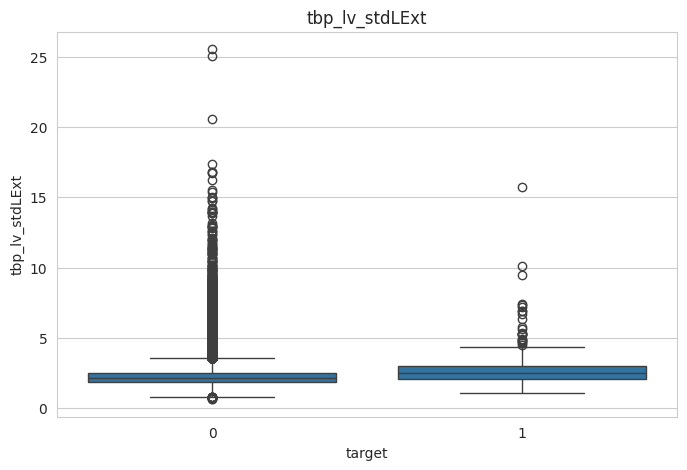

In [59]:
for col in top_features:

    plt.figure(figsize=(8,5))

    sns.boxplot(
        data=df,
        x="target",
        y=col
    )

    plt.title(col)

    plt.show()

# Feature Skewness

In [60]:
skewness = (

    df[numerical_cols]

    .skew()

    .sort_values(
        ascending=False
    )

)

skewness

target                          31.898510
tbp_lv_areaMM2                   5.908436
mel_thick_mm                     3.590869
tbp_lv_perimeterMM               3.123993
clin_size_long_diam_mm           2.831952
tbp_lv_stdLExt                   2.815049
tbp_lv_minorAxisMM               2.429612
tbp_lv_area_perim_ratio          1.982719
tbp_lv_deltaA                    1.808798
tbp_lv_radial_color_std_max      1.747608
tbp_lv_stdL                      1.582380
tbp_lv_color_std_mean            1.573142
tbp_lv_deltaLBnorm               1.348489
tbp_lv_deltaLB                   1.197946
tbp_lv_norm_border               1.158386
tbp_lv_norm_color                0.947674
tbp_lv_symm_2axis                0.835128
tbp_lv_A                         0.568612
tbp_lv_nevi_confidence           0.422379
tbp_lv_Aext                      0.419741
tbp_lv_Bext                      0.330380
tbp_lv_Cext                      0.227868
tbp_lv_B                         0.183855
tbp_lv_C                         0

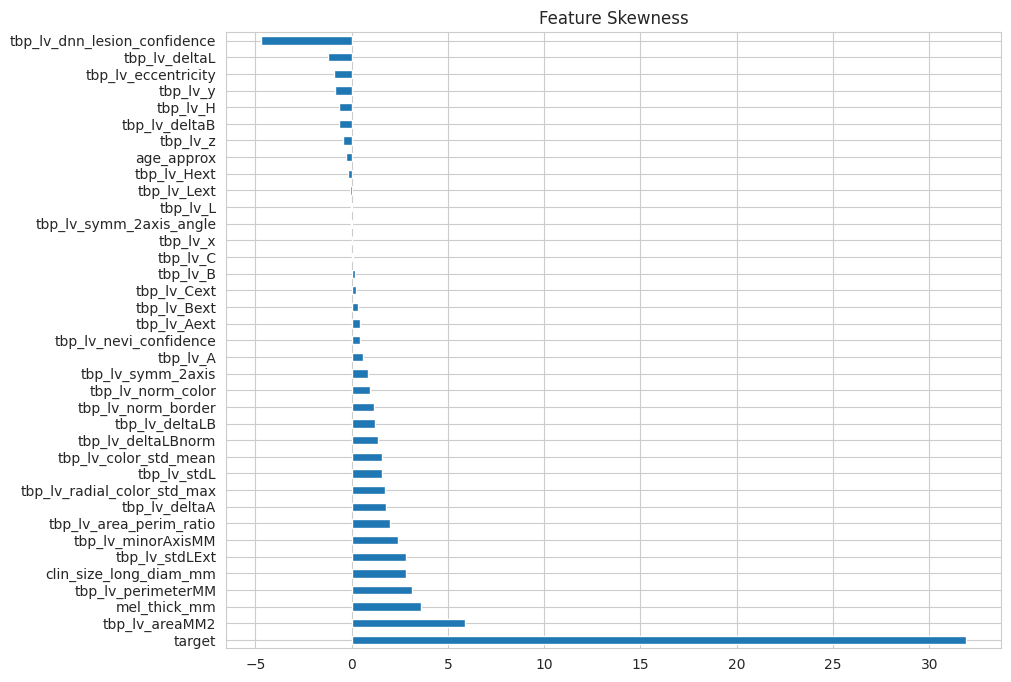

In [61]:
plt.figure(figsize=(10,8))

skewness.plot.barh()

plt.title("Feature Skewness")

plt.show()

# Categorical Features

In [62]:
categorical_cols = df.select_dtypes(include="object").columns.tolist()

print(len(categorical_cols))

categorical_cols

18


['isic_id',
 'patient_id',
 'sex',
 'anatom_site_general',
 'image_type',
 'tbp_tile_type',
 'tbp_lv_location',
 'tbp_lv_location_simple',
 'attribution',
 'copyright_license',
 'lesion_id',
 'iddx_full',
 'iddx_1',
 'iddx_2',
 'iddx_3',
 'iddx_4',
 'iddx_5',
 'mel_mitotic_index']

In [63]:
for col in categorical_cols[:5]:

    print("="*40)

    print(col)

    print(df[col].value_counts().head())

isic_id
isic_id
ISIC_9999967    1
ISIC_0015670    1
ISIC_0015845    1
ISIC_9999539    1
ISIC_9999520    1
Name: count, dtype: int64
patient_id
patient_id
IP_1117889    9184
IP_5714646    6267
IP_3921915    5568
IP_7797815    4454
IP_9577633    3583
Name: count, dtype: int64
sex
sex
male      265546
female    123996
Name: count, dtype: int64
anatom_site_general
anatom_site_general
posterior torso    121902
lower extremity    103028
anterior torso      87770
upper extremity     70557
head/neck           12046
Name: count, dtype: int64
image_type
image_type
TBP tile: close-up    401059
Name: count, dtype: int64


# Cardinality

In [64]:
cardinality = {

    col:df[col].nunique()

    for col in categorical_cols

}

pd.DataFrame(

cardinality.items(),

columns=["Column","Unique Values"]

).sort_values(

"Unique Values",

ascending=False

)

,Column,Unique Values
0,isic_id,401059
10,lesion_id,22058
1,patient_id,1042
11,iddx_full,52
15,iddx_4,26
14,iddx_3,25
6,tbp_lv_location,21
13,iddx_2,14
7,tbp_lv_location_simple,8
8,attribution,7


# Missing Values (Categorical)

In [65]:
df[categorical_cols].isnull().sum().sort_values(ascending=False)

iddx_5                    401058
mel_mitotic_index         401006
iddx_4                    400508
iddx_3                    399994
iddx_2                    399991
lesion_id                 379001
sex                        11517
anatom_site_general         5756
patient_id                     0
isic_id                        0
copyright_license              0
attribution                    0
tbp_lv_location_simple         0
tbp_lv_location                0
tbp_tile_type                  0
image_type                     0
iddx_1                         0
iddx_full                      0
dtype: int64

# Metadata Quality Check

In [66]:
quality = {

"Duplicate Rows":df.duplicated().sum(),

"Duplicate ISIC IDs":df["isic_id"].duplicated().sum(),

"Duplicate Patients":df["patient_id"].duplicated().sum(),

"Missing Cells":df.isnull().sum().sum()

}

quality

{'Duplicate Rows': np.int64(0),
 'Duplicate ISIC IDs': np.int64(0),
 'Duplicate Patients': np.int64(400017),
 'Missing Cells': np.int64(2802625)}

In [67]:
pd.DataFrame(

quality.items(),

columns=["Metric","Value"]

)

,Metric,Value
0,Duplicate Rows,0
1,Duplicate ISIC IDs,0
2,Duplicate Patients,400017
3,Missing Cells,2802625


# Top Numerical Features

In [68]:
importance = (

target_corr

.abs()

.sort_values(

ascending=False

)

)

importance

target                          1.000000
tbp_lv_dnn_lesion_confidence    0.054766
tbp_lv_areaMM2                  0.045139
tbp_lv_H                        0.044884
tbp_lv_perimeterMM              0.036188
tbp_lv_minorAxisMM              0.035757
tbp_lv_deltaB                   0.035069
clin_size_long_diam_mm          0.032682
tbp_lv_Hext                     0.032671
tbp_lv_B                        0.026366
tbp_lv_stdLExt                  0.026084
tbp_lv_radial_color_std_max     0.025441
tbp_lv_color_std_mean           0.024271
tbp_lv_Aext                     0.023206
tbp_lv_norm_color               0.022264
tbp_lv_A                        0.019788
tbp_lv_deltaLBnorm              0.015172
tbp_lv_Bext                     0.013711
tbp_lv_nevi_confidence          0.013341
tbp_lv_stdL                     0.012669
tbp_lv_deltaLB                  0.012237
tbp_lv_deltaL                   0.011256
tbp_lv_y                        0.009926
tbp_lv_area_perim_ratio         0.009624
tbp_lv_C        

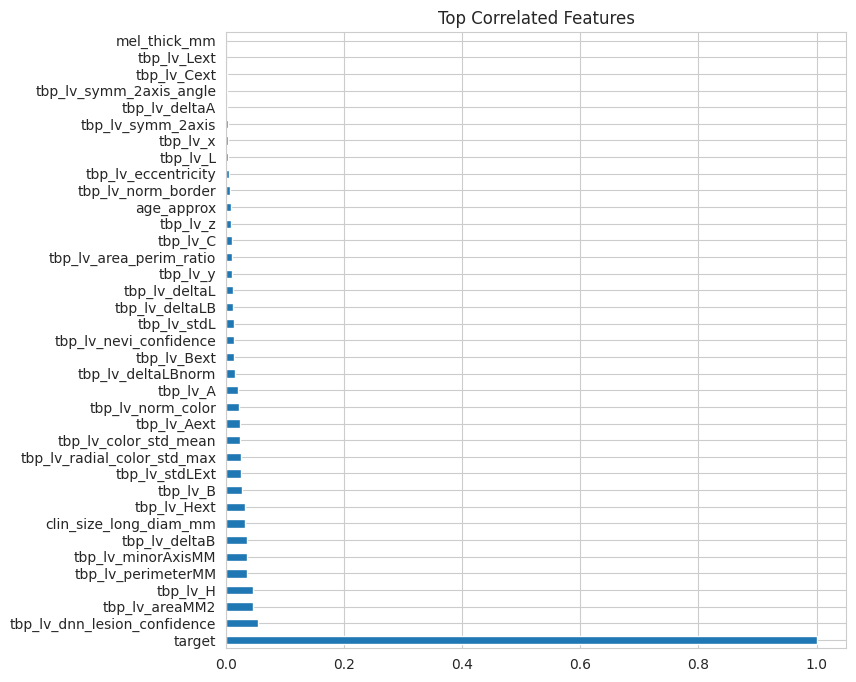

In [69]:
importance.plot.barh(figsize=(8,8))

plt.title("Top Correlated Features")

plt.show()

# Notebook Summary

In [70]:
summary = {

"Rows":len(df),

"Columns":len(df.columns),

"Patients":df["patient_id"].nunique(),

"Images":df["isic_id"].nunique(),

"Positive":int(df["target"].sum()),

"Negative":int(len(df)-df["target"].sum()),

"Missing Cells":int(df.isnull().sum().sum())

}

pd.DataFrame(

summary.items(),

columns=["Metric","Value"]

)

,Metric,Value
0,Rows,401059
1,Columns,55
2,Patients,1042
3,Images,401059
4,Positive,393
5,Negative,400666
6,Missing Cells,2802625


# EDA Progress

✅ Dataset Structure

✅ Metadata Analysis

✅ Patient Analysis

✅ Missing Values

✅ Class Imbalance

✅ Numerical Features

✅ Correlation Analysis

✅ Outlier Detection

Next Notebook:
03_Data_Preprocessing.ipynb